In [2]:
import numpy as mp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [3]:
#1 verifying 
df_airfryers = pd.read_csv("air_fryers_clean_brand_year.csv")
print(df_airfryers.shape)
print(df_airfryers.head())
print(df_airfryers["brand"].unique())
print(df_airfryers['year'].unique())
# length 10 present
# years 2019-2023 present

(50, 15)
     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119      

Length is 10 brands: 'chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster','ultrean'.
Years: 2019, 2020, 2021, 2022, 2023

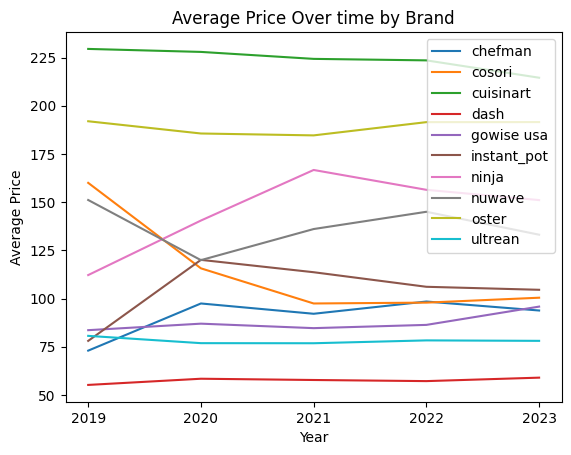

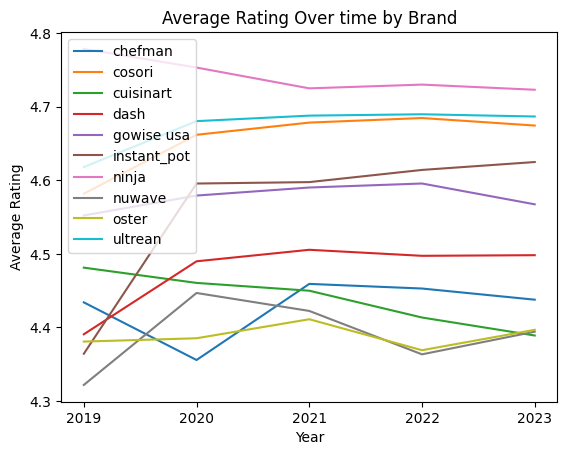

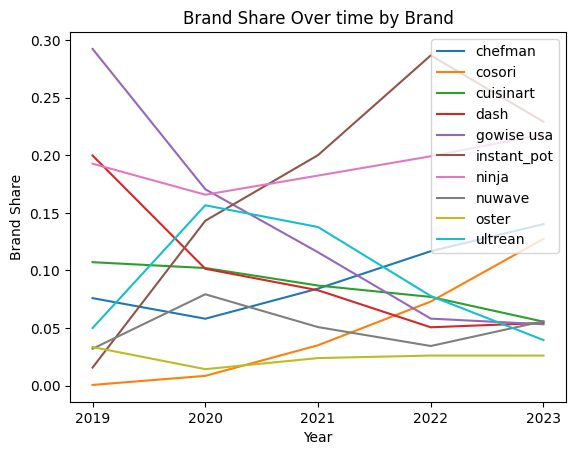

In [6]:
#plots
# average price over time by brand
plt.figure()

for brand in df_airfryers['brand'].unique():
    i = df_airfryers[df_airfryers['brand'] ==brand]
    plt.plot(i['year'], i['avg_price'], label=brand)

plt.title('Average Price Over time by Brand')
plt.xlabel('Year')
plt.xticks([2019,2020,2021, 2022, 2023])
plt.ylabel('Average Price')
plt.legend()
plt.show()

# average rating over time by brand
plt.figure()

for brand in df_airfryers['brand'].unique():
    i = df_airfryers[df_airfryers['brand'] ==brand]
    plt.plot(i['year'], i['avg_rating'], label=brand)

plt.title('Average Rating Over time by Brand')
plt.xlabel('Year')
plt.xticks([2019,2020,2021, 2022, 2023])
plt.ylabel('Average Rating')
plt.legend()
plt.show()

# brand market share over time by brand
plt.figure()

for brand in df_airfryers['brand'].unique():
    i = df_airfryers[df_airfryers['brand'] ==brand]
    plt.plot(i['year'], i['brand_share'], label=brand)


plt.title('Brand Share Over time by Brand')
plt.xlabel('Year')
plt.xticks([2019,2020,2021, 2022, 2023])
plt.ylabel('Brand Share')
plt.legend()
plt.show()

#3 Product Characteristics

Common Features: Compact design is the industry standard, with a compact_share near $1.0$ for almost all brands. Oven-style models are the secondary dominant format, particularly for premium brands.
Rare Features: Dual-basket models are nearly nonexistent in this dataset. Rotisserie and Window features are highly niche, appearing primarily in a small subset of models from brands like Chefman and GoWise USA.

Brand Specialization:
Premium/Oven Specialists: Cuisinart and Oster focus on high-priced, oven-style units.
Value Specialists: Dash and Ultrean focus almost exclusively on low-cost, compact models.
Feature Leaders: Chefman and GoWise USA are more likely to incorporate "rare" features like rotisserie functions compared to the rest of the market.



#4. Market Description
Price Positioning: The market is clearly tiered. Cuisinart and Oster maintain the premium ceiling (avg. price $>\$180$), while Dash and Ultrean anchor the entry-level segment (avg. price $<\$80$).
Market Share Leaders: Instant Pot and Ninja are the current titans. Instant Pot’s trajectory is the most impressive, rising from a negligible share in 2019 to becoming the market leader by 2022.
Stability Analysis (Correction): Contrary to being "stable," the market has been highly disruptive.
GoWise USA experienced a massive collapse, dropping from the #1 spot in shares in 2019 to a minor player by 2023.
Instant Pot and Cosori represent "disruptive growth," rapidly seizing share from older brands.
Quality vs. Competition: Because Average Ratings are consistently high ($4.3$ to $4.8$) across all brands, the market is not competing on basic quality. Instead, brands are fighting for dominance through pricing strategy and brand ecosystem (e.g., the "Instant Pot" brand halo).